## Heatmap

1. Подключение к db.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. SQL-запрос и функция для построения графиков.

In [2]:
query = """
SELECT uid, timestamp
FROM checker
WHERE uid NOT LIKE "admin%"
"""

df = pd.read_sql(query, conn)

def make_heatmap(matrix):
    fig, ax = plt.subplots(figsize=(15, 8))
    im = ax.imshow(matrix.values, cmap="inferno", interpolation='nearest')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    fig.colorbar(im, cax=cax)
    
    return ax

3. Формирование датафрейма matrix_week.

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["day_of_week"] = df["timestamp"].dt.day_name()
df_week = df.groupby(["uid", "day_of_week"]).size().unstack(fill_value=0)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_week = df_week.reindex(columns=days_order)

temp_df_week = df_week.sum(axis=1).sort_values(ascending=False)
sorted_wk = temp_df_week.index
df_week = df_week.reindex(index=sorted_wk)

matrix_week = df_week.transpose()
matrix_week

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,2,0,0,3
Tuesday,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,5,3,0,0,0
Wednesday,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,3,0,0,0,0
Thursday,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,2,0,6,0
Friday,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
Saturday,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
Sunday,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,0,1,8,0,0


4. Построение графика по дням недели.

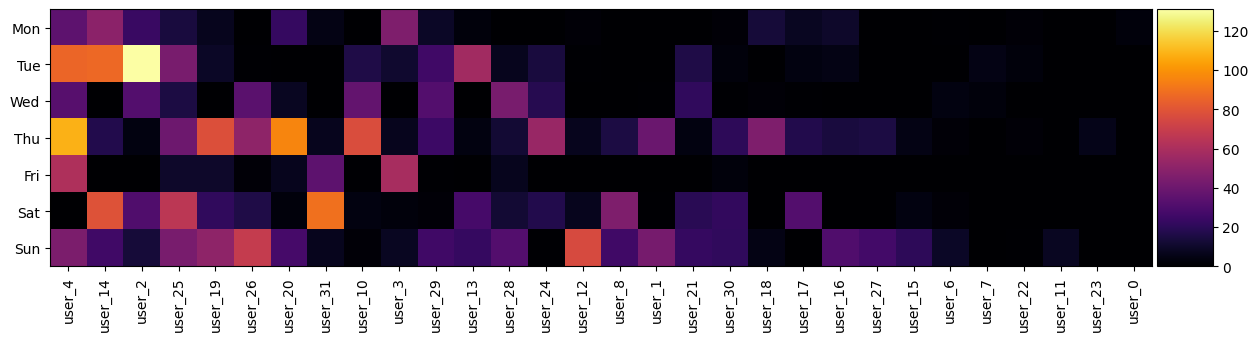

In [4]:
ax = make_heatmap(matrix_week)

days_order_reduct = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax.set_xticks(range(len(matrix_week.columns.tolist())), matrix_week.columns.tolist(), rotation=90)
ax.set_yticks(range(len(days_order)), days_order_reduct)

plt.show()

5. Формирование датафрейма matrix_hour.

In [5]:
df["hour"] = df["timestamp"].dt.hour
df_hour = df.groupby(["uid", "hour"]).size().unstack(fill_value=0)

temp_df_hour = df_hour.sum(axis=1).sort_values(ascending=False)
sorted_ht = temp_df_hour.index

df_hour = df_hour.reindex(index=sorted_ht)
df_hour = df_hour.reindex(columns=range(24)).fillna(0)

matrix_hour = df_hour.transpose()
matrix_hour

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


6. Построение графика по часам.

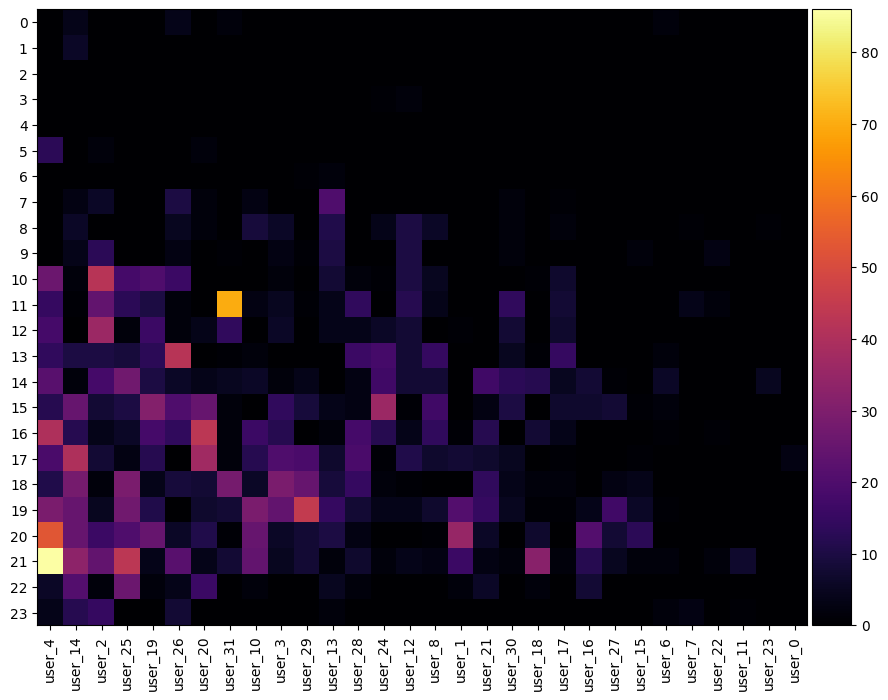

In [6]:
ax = make_heatmap(matrix_hour)

ax.set_xticks(range(len(matrix_hour.columns.tolist())), matrix_hour.columns.tolist(), rotation=90)
ax.set_yticks(range(24))

plt.show()

In [7]:
conn.close()

Вопросы:

У какого пользователя больше всего коммитов во вторник? Ответ: user_2.

У какого пользователя больше всего коммитов в четверг? Ответ: user_4.

В какой день недели пользователи не любят делать много коммитов? Ответ: Пятница

У какого пользователя в какое время было наибольшее количество коммитов? Ответ: user_4 в 21:00
